In [ ]:
# TEXTRANK EXTRACTIVE SUMMARISATION
# 1,3,5,7 SENTENCE SUMMARIES
# FULL DATASET
# SAVE CSV FILES + EVALUATION
# =========================

!pip install -q pandas numpy nltk scikit-learn rouge-score networkx

import re
import time
import numpy as np
import pandas as pd
import nltk
import networkx as nx

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

# -------------------------
# 1. LOAD DATASET
# -------------------------
DATA_PATH = "/content/IMDB Dataset.csv"

df = pd.read_csv(DATA_PATH)
print("Original dataset shape:", df.shape)
display(df.head())

# -------------------------
# 2. PREPROCESSING
# -------------------------
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df = df.dropna(subset=["review", "sentiment"]).drop_duplicates().reset_index(drop=True)
df["clean_text"] = df["review"].apply(clean_text)
df["label"] = df["sentiment"].map({"positive": 1, "negative": 0})

print("\nCleaned dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())

# -------------------------
# 3. TRAIN / VALIDATION / TEST SPLIT
# -------------------------
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["clean_text"],
    df["label"],
    test_size=0.3,
    stratify=df["label"],
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

train_texts = train_texts.tolist()
val_texts = val_texts.tolist()
test_texts = test_texts.tolist()

train_labels = train_labels.tolist()
val_labels = val_labels.tolist()
test_labels = test_labels.tolist()

print("\nSplit sizes:")
print("Train:", len(train_texts))
print("Validation:", len(val_texts))
print("Test:", len(test_texts))

# -------------------------
# 4. FULL DATASET
# -------------------------
train_subset = train_texts
val_subset = val_texts
test_subset = test_texts

train_subset_labels = train_labels
val_subset_labels = val_labels
test_subset_labels = test_labels

# -------------------------
# 5. TEXTRANK FUNCTION
# -------------------------
def textrank_summary(text, n_sentences):
    sentences = sent_tokenize(str(text))

    if len(sentences) == 0:
        return ""
    if len(sentences) <= n_sentences:
        return " ".join(sentences)

    try:
        vectorizer = TfidfVectorizer(stop_words="english")
        X = vectorizer.fit_transform(sentences)

        if X.shape[0] < 2 or X.shape[1] < 2:
            return " ".join(sentences[:n_sentences])

        similarity_matrix = cosine_similarity(X)
        np.fill_diagonal(similarity_matrix, 0)

        graph = nx.from_numpy_array(similarity_matrix)
        scores = nx.pagerank(graph)

        ranked = sorted(
            ((scores[i], i, s) for i, s in enumerate(sentences)),
            reverse=True
        )

        selected = sorted(ranked[:n_sentences], key=lambda x: x[1])
        summary = " ".join([item[2] for item in selected])

        return summary

    except Exception:
        return " ".join(sentences[:n_sentences])

# -------------------------
# 6. GENERATE SUMMARIES
# -------------------------
def generate_split_summaries(texts, labels, split_name):
    summaries1 = []
    summaries3 = []
    summaries5 = []
    summaries7 = []

    start_time = time.time()

    for i, text in enumerate(texts):
        summaries1.append(textrank_summary(text, 1))
        summaries3.append(textrank_summary(text, 3))
        summaries5.append(textrank_summary(text, 5))
        summaries7.append(textrank_summary(text, 7))

        if (i + 1) % 5000 == 0:
            print(f"{split_name}: processed {i+1}/{len(texts)}")

    generation_time = time.time() - start_time
    print(f"\n{split_name} generation time: {round(generation_time, 2)} seconds")

    df1 = pd.DataFrame({
        "original_text": texts,
        "summary_text": summaries1,
        "label": labels
    })
    df3 = pd.DataFrame({
        "original_text": texts,
        "summary_text": summaries3,
        "label": labels
    })
    df5 = pd.DataFrame({
        "original_text": texts,
        "summary_text": summaries5,
        "label": labels
    })
    df7 = pd.DataFrame({
        "original_text": texts,
        "summary_text": summaries7,
        "label": labels
    })

    df1.to_csv(f"/content/{split_name}_textrank_1_sentence.csv", index=False)
    df3.to_csv(f"/content/{split_name}_textrank_3_sentences.csv", index=False)
    df5.to_csv(f"/content/{split_name}_textrank_5_sentences.csv", index=False)
    df7.to_csv(f"/content/{split_name}_textrank_7_sentences.csv", index=False)

    print(f"Saved /content/{split_name}_textrank_1_sentence.csv")
    print(f"Saved /content/{split_name}_textrank_3_sentences.csv")
    print(f"Saved /content/{split_name}_textrank_5_sentences.csv")
    print(f"Saved /content/{split_name}_textrank_7_sentences.csv")

    return df1, df3, df5, df7, generation_time

# -------------------------
# 7. RUN SUMMARISATION
# -------------------------
train1, train3, train5, train7, train_time = generate_split_summaries(
    train_subset, train_subset_labels, "train"
)

val1, val3, val5, val7, val_time = generate_split_summaries(
    val_subset, val_subset_labels, "val"
)

test1, test3, test5, test7, test_time = generate_split_summaries(
    test_subset, test_subset_labels, "test"
)

# -------------------------
# 8. SAMPLE OUTPUT
# -------------------------
if len(train_subset) > 0:
    print("\n============= SAMPLE =============\n")

    print("Original review:\n")
    print(train_subset[0][:700])

    print("\n1-sentence summary:\n")
    print(train1.iloc[0]["summary_text"][:700])

    print("\n3-sentence summary:\n")
    print(train3.iloc[0]["summary_text"][:700])

    print("\n5-sentence summary:\n")
    print(train5.iloc[0]["summary_text"][:700])

    print("\n7-sentence summary:\n")
    print(train7.iloc[0]["summary_text"][:700])

# -------------------------
# 9. EVALUATION FUNCTION
# -------------------------
def evaluate_extractive_summaries(original_texts, summary_texts, dataset_name):
    original_word_counts = []
    summary_word_counts = []
    original_sentence_counts = []
    summary_sentence_counts = []

    rouge1_scores = []
    rouge2_scores = []
    rougel_scores = []
    bleu_scores = []

    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
    smoothie = SmoothingFunction().method1

    for original, summary in zip(original_texts, summary_texts):
        original = str(original)
        summary = str(summary)

        orig_words = len(word_tokenize(original))
        summ_words = len(word_tokenize(summary))
        orig_sents = len(sent_tokenize(original))
        summ_sents = len(sent_tokenize(summary))

        original_word_counts.append(orig_words)
        summary_word_counts.append(summ_words)
        original_sentence_counts.append(orig_sents)
        summary_sentence_counts.append(summ_sents)

        try:
            scores = scorer.score(original, summary)
            rouge1_scores.append(scores["rouge1"].fmeasure)
            rouge2_scores.append(scores["rouge2"].fmeasure)
            rougel_scores.append(scores["rougeL"].fmeasure)
        except Exception:
            rouge1_scores.append(np.nan)
            rouge2_scores.append(np.nan)
            rougel_scores.append(np.nan)

        try:
            reference = [word_tokenize(original)]
            candidate = word_tokenize(summary)
            bleu = sentence_bleu(reference, candidate, smoothing_function=smoothie)
            bleu_scores.append(bleu)
        except Exception:
            bleu_scores.append(np.nan)

    avg_original_words = np.mean(original_word_counts)
    avg_summary_words = np.mean(summary_word_counts)
    avg_original_sentences = np.mean(original_sentence_counts)
    avg_summary_sentences = np.mean(summary_sentence_counts)

    word_compression_ratio = avg_summary_words / avg_original_words if avg_original_words > 0 else np.nan
    sentence_compression_ratio = avg_summary_sentences / avg_original_sentences if avg_original_sentences > 0 else np.nan

    avg_rouge1 = np.nanmean(rouge1_scores)
    avg_rouge2 = np.nanmean(rouge2_scores)
    avg_rougel = np.nanmean(rougel_scores)
    avg_bleu = np.nanmean(bleu_scores)

    print("\n================================")
    print("EVALUATION:", dataset_name)
    print("================================")
    print("Average Original Words:", round(avg_original_words, 2))
    print("Average Summary Words:", round(avg_summary_words, 2))
    print("Average Original Sentences:", round(avg_original_sentences, 2))
    print("Average Summary Sentences:", round(avg_summary_sentences, 2))
    print("Word Compression Ratio:", round(word_compression_ratio, 4))
    print("Sentence Compression Ratio:", round(sentence_compression_ratio, 4))
    print("Average ROUGE-1:", round(avg_rouge1, 4))
    print("Average ROUGE-2:", round(avg_rouge2, 4))
    print("Average ROUGE-L:", round(avg_rougel, 4))
    print("Average BLEU:", round(avg_bleu, 4))

    return {
        "Dataset": dataset_name,
        "Avg Original Words": round(avg_original_words, 2),
        "Avg Summary Words": round(avg_summary_words, 2),
        "Avg Original Sentences": round(avg_original_sentences, 2),
        "Avg Summary Sentences": round(avg_summary_sentences, 2),
        "Word Compression Ratio": round(word_compression_ratio, 4),
        "Sentence Compression Ratio": round(sentence_compression_ratio, 4),
        "ROUGE-1": round(avg_rouge1, 4),
        "ROUGE-2": round(avg_rouge2, 4),
        "ROUGE-L": round(avg_rougel, 4),
        "BLEU": round(avg_bleu, 4)
    }

# -------------------------
# 10. RUN EVALUATION
# -------------------------
evaluation_results = []

evaluation_results.append(evaluate_extractive_summaries(train_subset, train1["summary_text"], "train_textrank_1_sentence"))
evaluation_results.append(evaluate_extractive_summaries(train_subset, train3["summary_text"], "train_textrank_3_sentences"))
evaluation_results.append(evaluate_extractive_summaries(train_subset, train5["summary_text"], "train_textrank_5_sentences"))
evaluation_results.append(evaluate_extractive_summaries(train_subset, train7["summary_text"], "train_textrank_7_sentences"))

evaluation_results.append(evaluate_extractive_summaries(val_subset, val1["summary_text"], "val_textrank_1_sentence"))
evaluation_results.append(evaluate_extractive_summaries(val_subset, val3["summary_text"], "val_textrank_3_sentences"))
evaluation_results.append(evaluate_extractive_summaries(val_subset, val5["summary_text"], "val_textrank_5_sentences"))
evaluation_results.append(evaluate_extractive_summaries(val_subset, val7["summary_text"], "val_textrank_7_sentences"))

evaluation_results.append(evaluate_extractive_summaries(test_subset, test1["summary_text"], "test_textrank_1_sentence"))
evaluation_results.append(evaluate_extractive_summaries(test_subset, test3["summary_text"], "test_textrank_3_sentences"))
evaluation_results.append(evaluate_extractive_summaries(test_subset, test5["summary_text"], "test_textrank_5_sentences"))
evaluation_results.append(evaluate_extractive_summaries(test_subset, test7["summary_text"], "test_textrank_7_sentences"))

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df.to_csv("/content/textrank_extractive_summary_evaluation.csv", index=False)

print("\nSaved evaluation results:")
print("/content/textrank_extractive_summary_evaluation.csv")
display(evaluation_df)

print("\nAll TextRank summary CSV files generated successfully.")

  Preparing metadata (setup.py) ... done


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Original dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



Cleaned dataset shape: (49582, 4)

Label distribution:
label
1    24884
0    24698
Name: count, dtype: int64

Split sizes:
Train: 34707
Validation: 7437
Test: 7438
train: processed 5000/34707
train: processed 10000/34707
train: processed 15000/34707
train: processed 20000/34707
train: processed 25000/34707
train: processed 30000/34707

train generation time: 714.99 seconds
Saved /content/train_textrank_1_sentence.csv
Saved /content/train_textrank_3_sentences.csv
Saved /content/train_textrank_5_sentences.csv
Saved /content/train_textrank_7_sentences.csv
val: processed 5000/7437

val generation time: 151.33 seconds
Saved /content/val_textrank_1_sentence.csv
Saved /content/val_textrank_3_sentences.csv
Saved /content/val_textrank_5_sentences.csv
Saved /content/val_textrank_7_sentences.csv
test: processed 5000/7438

test generation time: 150.73 seconds
Saved /content/test_textrank_1_sentence.csv
Saved /content/test_textrank_3_sentences.csv
Saved /content/test_textrank_5_sentences.csv
Saved

,Dataset,Avg Original Words,Avg Summary Words,Avg Original Sentences,Avg Summary Sentences,Word Compression Ratio,Sentence Compression Ratio,ROUGE-1,ROUGE-2,ROUGE-L,BLEU
0,train_textrank_1_sentence,265.46,27.84,12.37,1.01,0.1049,0.0818,0.2324,0.2243,0.2324,0.0336
1,train_textrank_3_sentences,265.46,76.82,12.37,2.98,0.2894,0.2407,0.5260,0.5134,0.5260,0.2433
2,train_textrank_5_sentences,265.46,119.47,12.37,4.84,0.4500,0.3910,0.7037,0.6921,0.7037,0.4804
3,train_textrank_7_sentences,265.46,154.43,12.37,6.47,0.5817,0.5226,0.8138,0.8048,0.8138,0.6587
4,val_textrank_1_sentence,264.61,27.69,12.34,1.01,0.1047,0.0820,0.2313,0.2231,0.2313,0.0324
5,val_textrank_3_sentences,264.61,76.82,12.34,2.98,0.2903,0.2415,0.5279,0.5153,0.5279,0.2468
6,val_textrank_5_sentences,264.61,119.33,12.34,4.83,0.4510,0.3917,0.7063,0.6948,0.7063,0.4854
7,val_textrank_7_sentences,264.61,153.79,12.34,6.45,0.5812,0.5222,0.8147,0.8058,0.8147,0.6604
8,test_textrank_1_sentence,263.14,28.14,12.15,1.01,0.1070,0.0831,0.2350,0.2269,0.2350,0.0337
9,test_textrank_3_sentences,263.14,77.38,12.15,2.98,0.2941,0.2452,0.5297,0.5170,0.5297,0.2471



All TextRank summary CSV files generated successfully.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil

destination = "/content/drive/MyDrive/MSc_Project/textrank_summaries"
os.makedirs(destination, exist_ok=True)

for file in os.listdir("/content"):
    if file.endswith(".csv"):
        shutil.copy(os.path.join("/content", file), destination)

print("All CSV files copied to Google Drive.")
print("Saved in:", destination)

All CSV files copied to Google Drive.
Saved in: /content/drive/MyDrive/MSc_Project/textrank_summaries


Device: Tesla T4

RUNNING: BERT | Summarised Text | TextRank | 1 Sentence


Token indices sequence length is longer than the specified maximum sequence length for this model (557 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 32.85
Train avg tokens after trunc: 32.74
Train truncation %: 0.14
Validation avg tokens after trunc: 32.53
Test avg tokens after trunc: 33.06
Test truncation %: 0.15


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.503578,0.472423,0.777733,0.756098,0.822347,0.787832,0.865607
2,0.339108,0.602228,0.785128,0.776425,0.803055,0.789515,0.869271


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.7873
Precision: 0.775
Recall: 0.8119
F1: 0.793
ROC-AUC: 0.8732
Training time (min): 13.31
Training time per epoch (min): 6.65
Inference time (sec): 18.89
Inference latency per sample (ms): 2.5395
Training throughput (samples/sec): 43.47
Inference throughput (samples/sec): 393.77
Peak training GPU memory (MB): 2307.86
Peak inference GPU memory (MB): 1526.84

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.80      0.76      0.78      3705
    Positive       0.77      0.81      0.79      3733

    accuracy                           0.79      7438
   macro avg       0.79      0.79      0.79      7438
weighted avg       0.79      0.79      0.79      7438



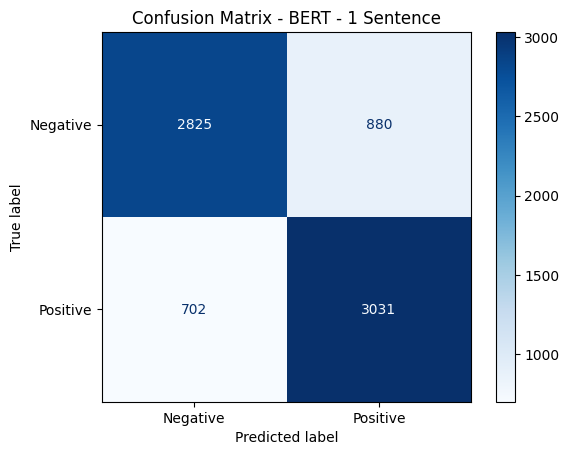

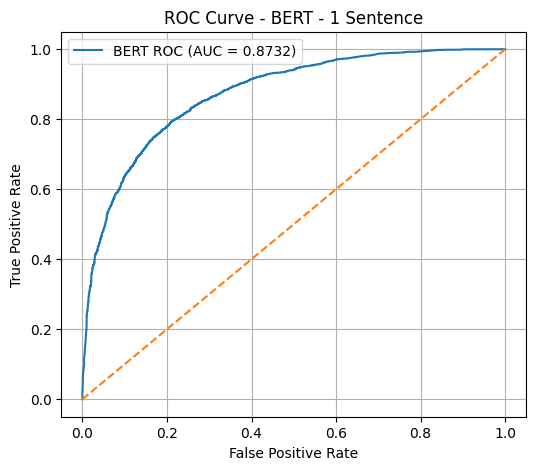

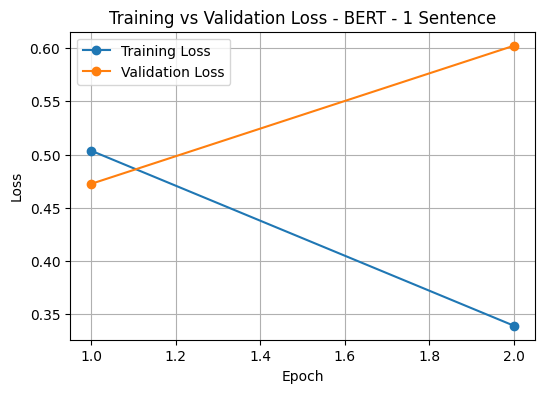


RUNNING: XLNet | Summarised Text | TextRank | 1 Sentence


config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 34.25
Train avg tokens after trunc: 34.11
Train truncation %: 0.17
Validation avg tokens after trunc: 33.86
Test avg tokens after trunc: 34.45
Test truncation %: 0.19


...

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.503594,0.458470,0.787011,0.778672,0.804126,0.791194,0.873237
2,0.368412,0.525614,0.790507,0.779866,0.811629,0.795431,0.879140


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.7999
Precision: 0.7831
Recall: 0.8318
F1: 0.8067
ROC-AUC: 0.8879
Training time (min): 18.35
Training time per epoch (min): 9.18
Inference time (sec): 29.41
Inference latency per sample (ms): 3.9538
Training throughput (samples/sec): 31.52
Inference throughput (samples/sec): 252.92
Peak training GPU memory (MB): 3188.95
Peak inference GPU memory (MB): 1750.42

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.82      0.77      0.79      3705
    Positive       0.78      0.83      0.81      3733

    accuracy                           0.80      7438
   macro avg       0.80      0.80      0.80      7438
weighted avg       0.80      0.80      0.80      7438



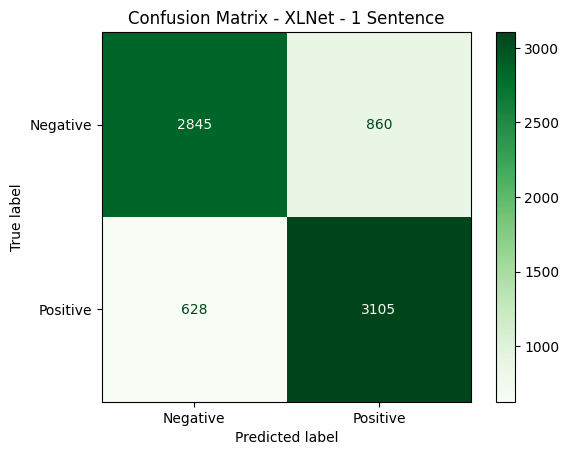

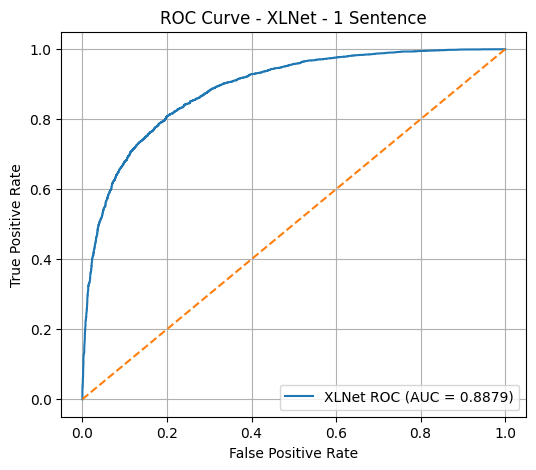

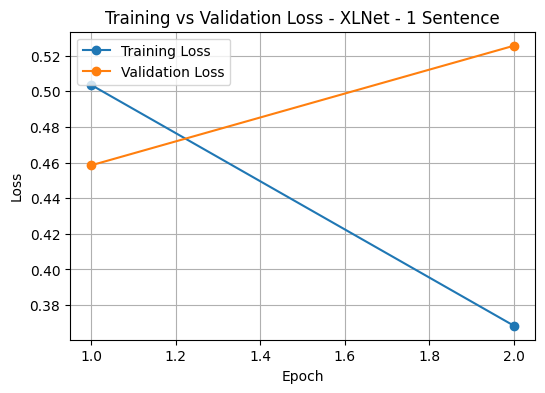


RUNNING: BERT | Summarised Text | TextRank | 3 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (1113 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 86.88
Train avg tokens after trunc: 86.36
Train truncation %: 0.69
Validation avg tokens after trunc: 86.45
Test avg tokens after trunc: 86.97
Test truncation %: 0.91


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.373184,0.344569,0.868226,0.851738,0.892819,0.871795,0.946950
2,0.233938,0.452339,0.877370,0.877409,0.878349,0.877879,0.950143


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.8755
Precision: 0.8724
Recall: 0.8808
F1: 0.8766
ROC-AUC: 0.9499
Training time (min): 16.29
Training time per epoch (min): 8.14
Inference time (sec): 22.97
Inference latency per sample (ms): 3.0881
Training throughput (samples/sec): 35.52
Inference throughput (samples/sec): 323.82
Peak training GPU memory (MB): 2310.4
Peak inference GPU memory (MB): 1529.72

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.88      0.87      0.87      3705
    Positive       0.87      0.88      0.88      3733

    accuracy                           0.88      7438
   macro avg       0.88      0.88      0.88      7438
weighted avg       0.88      0.88      0.88      7438



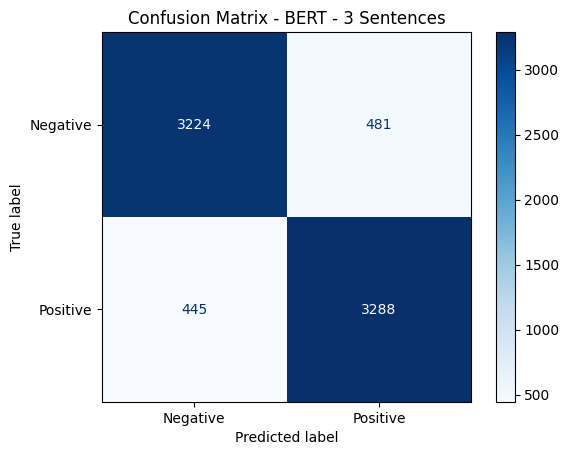

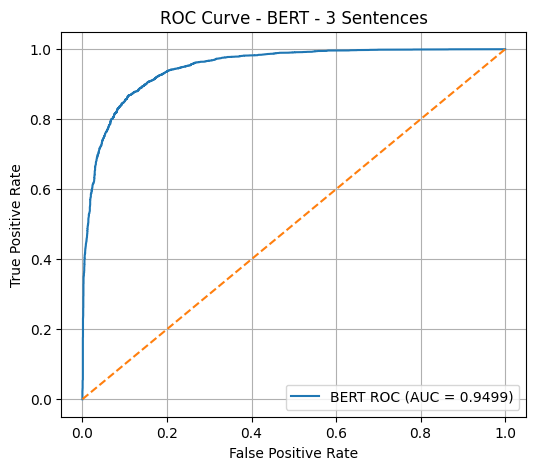

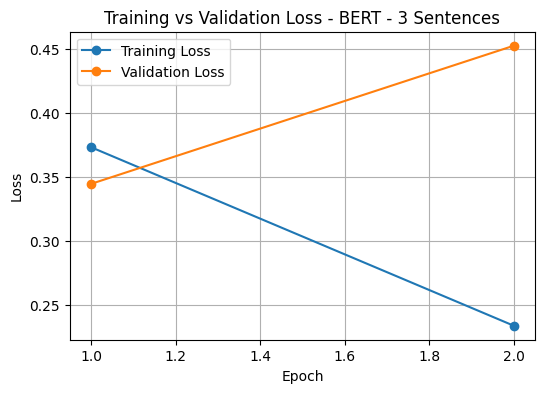


RUNNING: XLNet | Summarised Text | TextRank | 3 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 90.59
Train avg tokens after trunc: 89.9
Train truncation %: 0.95
Validation avg tokens after trunc: 89.95
Test avg tokens after trunc: 90.55
Test truncation %: 1.22


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.367920,0.386603,0.884093,0.904453,0.859861,0.881593,0.954140
2,0.248299,0.449989,0.892968,0.889597,0.898178,0.893867,0.958843


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.8931
Precision: 0.884
Recall: 0.906
F1: 0.8948
ROC-AUC: 0.9584
Training time (min): 23.15
Training time per epoch (min): 11.58
Inference time (sec): 39.48
Inference latency per sample (ms): 5.3085
Training throughput (samples/sec): 24.98
Inference throughput (samples/sec): 188.38
Peak training GPU memory (MB): 3177.83
Peak inference GPU memory (MB): 1756.3

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      3705
    Positive       0.88      0.91      0.89      3733

    accuracy                           0.89      7438
   macro avg       0.89      0.89      0.89      7438
weighted avg       0.89      0.89      0.89      7438



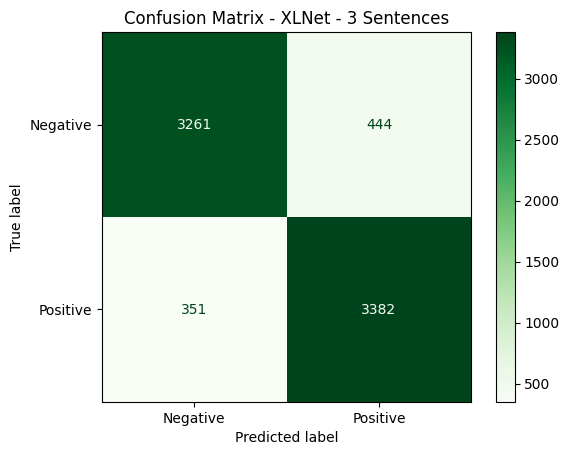

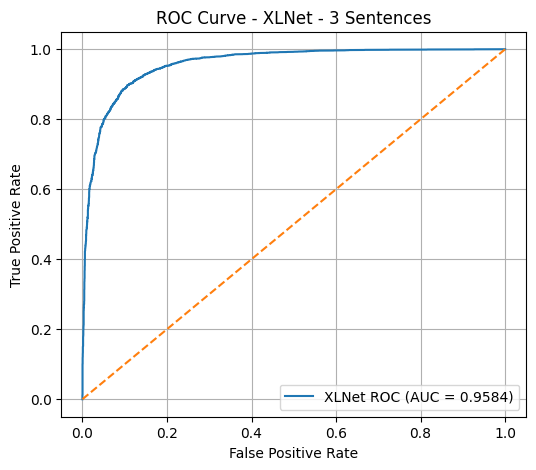

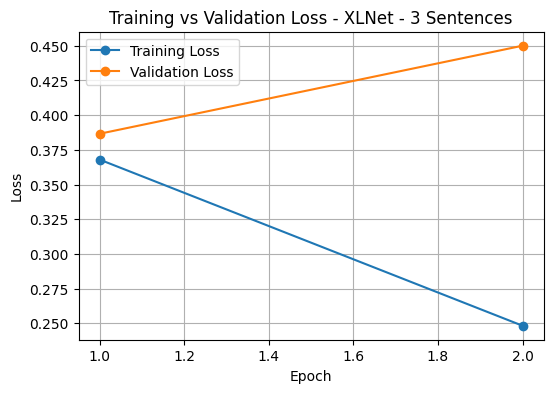


RUNNING: BERT | Summarised Text | TextRank | 5 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (577 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 133.85
Train avg tokens after trunc: 131.9
Train truncation %: 3.06
Validation avg tokens after trunc: 131.95
Test avg tokens after trunc: 132.43
Test truncation %: 3.41


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.329232,0.252752,0.911927,0.907334,0.918274,0.912771,0.969687
2,0.186383,0.349084,0.912868,0.916982,0.908628,0.912786,0.971989


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9109
Precision: 0.9076
Recall: 0.9156
F1: 0.9116
ROC-AUC: 0.9692
Training time (min): 19.25
Training time per epoch (min): 9.63
Inference time (sec): 29.11
Inference latency per sample (ms): 3.914
Training throughput (samples/sec): 30.05
Inference throughput (samples/sec): 255.49
Peak training GPU memory (MB): 2300.05
Peak inference GPU memory (MB): 1525.55

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.91      0.91      0.91      3705
    Positive       0.91      0.92      0.91      3733

    accuracy                           0.91      7438
   macro avg       0.91      0.91      0.91      7438
weighted avg       0.91      0.91      0.91      7438



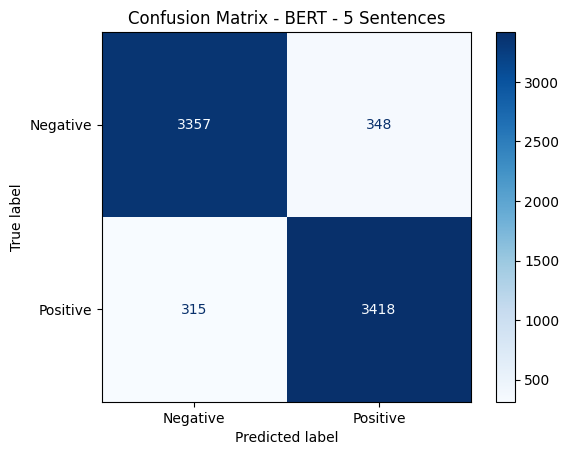

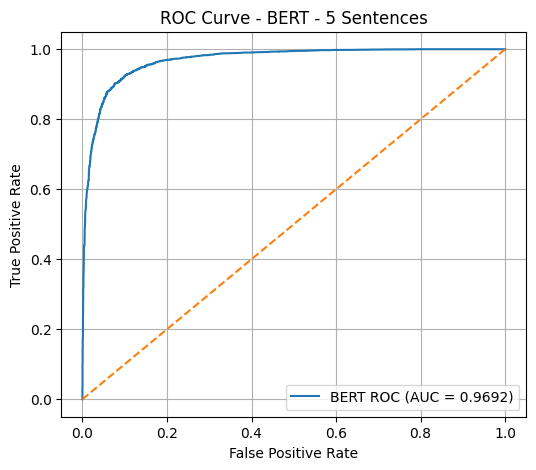

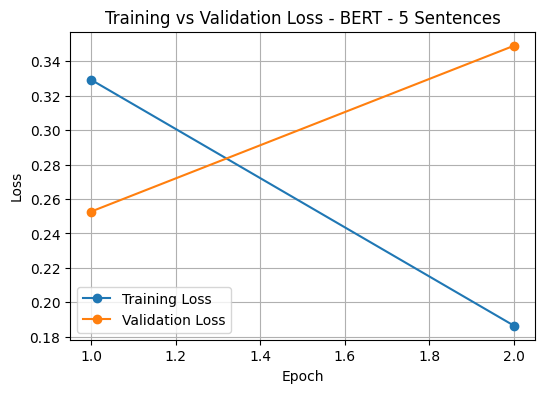


RUNNING: XLNet | Summarised Text | TextRank | 5 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 139.5
Train avg tokens after trunc: 136.9
Train truncation %: 3.96
Validation avg tokens after trunc: 136.93
Test avg tokens after trunc: 137.45
Test truncation %: 4.34


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.317829,0.286128,0.917709,0.910959,0.926581,0.918704,0.974242
2,0.192456,0.343544,0.923491,0.919830,0.928457,0.924123,0.977525


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9226
Precision: 0.9168
Recall: 0.9301
F1: 0.9234
ROC-AUC: 0.9758
Training time (min): 29.03
Training time per epoch (min): 14.51
Inference time (sec): 50.91
Inference latency per sample (ms): 6.8452
Training throughput (samples/sec): 19.93
Inference throughput (samples/sec): 146.09
Peak training GPU memory (MB): 3169.97
Peak inference GPU memory (MB): 1738.58

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92      3705
    Positive       0.92      0.93      0.92      3733

    accuracy                           0.92      7438
   macro avg       0.92      0.92      0.92      7438
weighted avg       0.92      0.92      0.92      7438



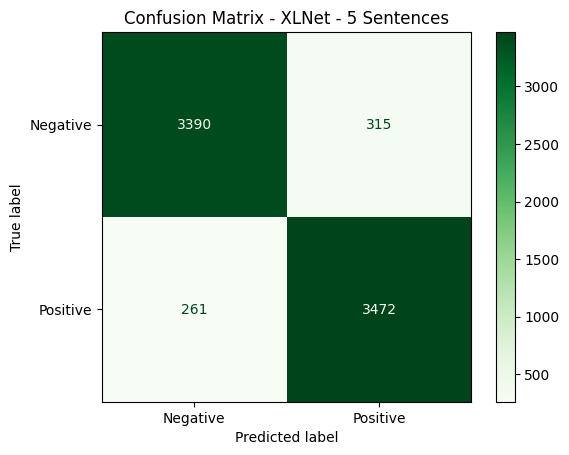

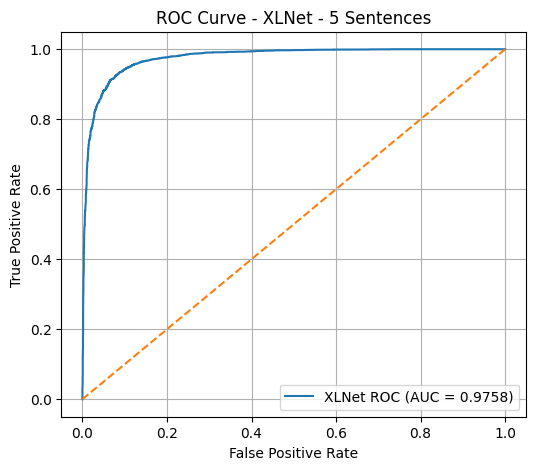

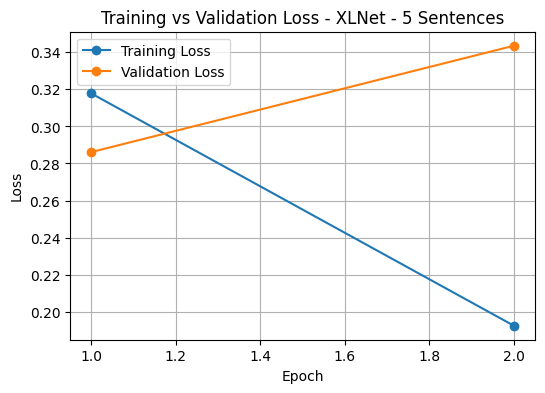


RUNNING: BERT | Summarised Text | TextRank | 7 Sentences


Token indices sequence length is longer than the specified maximum sequence length for this model (579 > 512). Running this sequence through the model will result in indexing errors



=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 172.35
Train avg tokens after trunc: 166.04
Train truncation %: 10.0
Validation avg tokens after trunc: 165.58
Test avg tokens after trunc: 166.35
Test truncation %: 10.15


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.305542,0.263230,0.923087,0.924960,0.921490,0.923221,0.974230
2,0.167102,0.318606,0.923760,0.919650,0.929260,0.924430,0.978285


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


=== RESULTS ===
Accuracy: 0.9236
Precision: 0.9166
Recall: 0.9328
F1: 0.9246
ROC-AUC: 0.9777
Training time (min): 21.73
Training time per epoch (min): 10.87
Inference time (sec): 34.39
Inference latency per sample (ms): 4.6241
Training throughput (samples/sec): 26.62
Inference throughput (samples/sec): 216.26
Peak training GPU memory (MB): 2299.86
Peak inference GPU memory (MB): 1523.34

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.93      0.91      0.92      3705
    Positive       0.92      0.93      0.92      3733

    accuracy                           0.92      7438
   macro avg       0.92      0.92      0.92      7438
weighted avg       0.92      0.92      0.92      7438



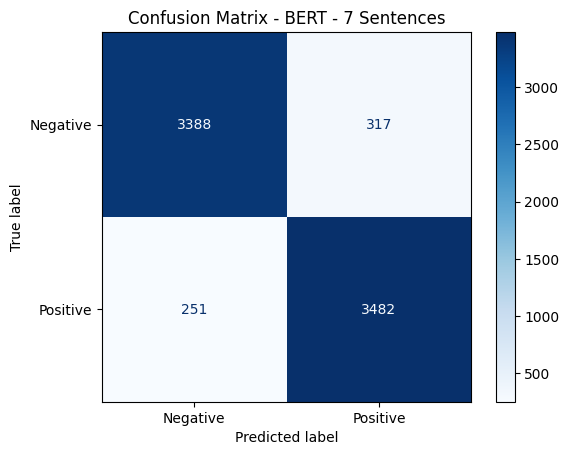

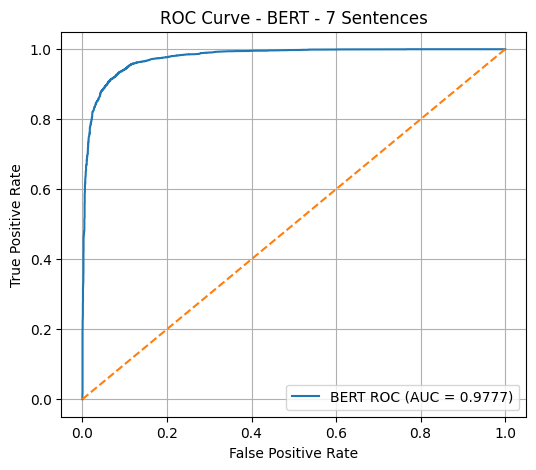

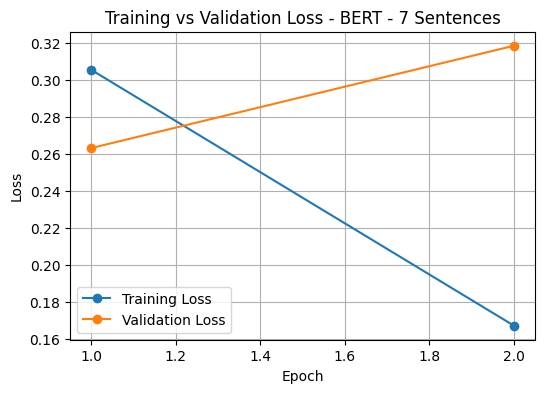


RUNNING: XLNet | Summarised Text | TextRank | 7 Sentences

=== TOKEN / TRUNCATION STATS ===
Train avg tokens before trunc: 179.55
Train avg tokens after trunc: 171.42
Train truncation %: 12.14
Validation avg tokens after trunc: 170.89
Test avg tokens after trunc: 171.69
Test truncation %: 12.38


Loading weights:   0%|          | 0/206 [00:00<?, ?it/s]

XLNetForSequenceClassification LOAD REPORT from: xlnet-base-cased
Key                             | Status     | 
--------------------------------+------------+-
lm_loss.bias                    | UNEXPECTED | 
lm_loss.weight                  | UNEXPECTED | 
sequence_summary.summary.bias   | MISSING    | 
logits_proj.bias                | MISSING    | 
logits_proj.weight              | MISSING    | 
sequence_summary.summary.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.291944,0.246044,0.931155,0.912609,0.954180,0.932932,0.981405
2,0.167900,0.282972,0.939088,0.937317,0.941586,0.939447,0.983298


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


=== RESULTS ===
Accuracy: 0.9347
Precision: 0.9326
Recall: 0.9376
F1: 0.9351
ROC-AUC: 0.983
Training time (min): 31.89
Training time per epoch (min): 15.94
Inference time (sec): 57.05
Inference latency per sample (ms): 7.67
Training throughput (samples/sec): 18.14
Inference throughput (samples/sec): 130.38
Peak training GPU memory (MB): 3169.95
Peak inference GPU memory (MB): 1754.72

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Negative       0.94      0.93      0.93      3705
    Positive       0.93      0.94      0.94      3733

    accuracy                           0.93      7438
   macro avg       0.93      0.93      0.93      7438
weighted avg       0.93      0.93      0.93      7438



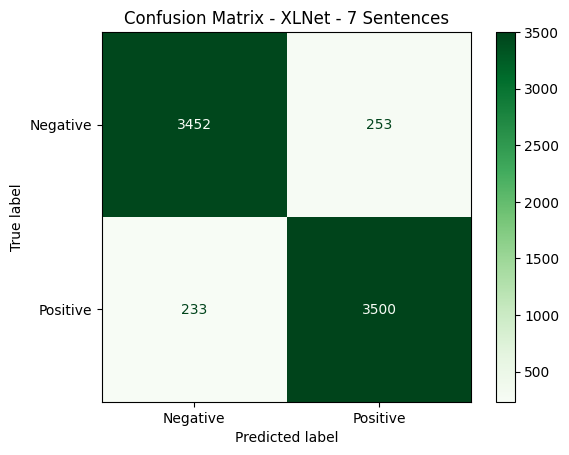

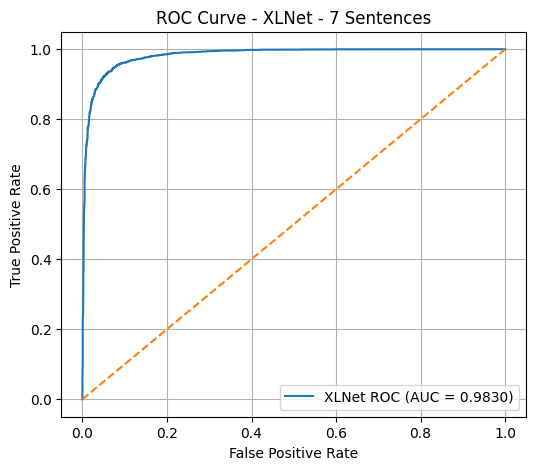

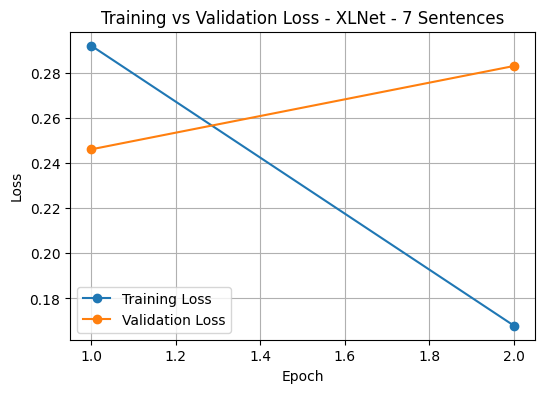


FINAL TEXTRANK CLASSIFICATION RESULTS


,Input Type,Summary Method,Summary Length,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Train Samples,...,Test Truncation %,Training Time (min),Training Time per Epoch (min),Inference Time (sec),Inference Latency per Sample (ms),Training Throughput (samples/sec),Inference Throughput (samples/sec),Peak Training GPU Memory (MB),Peak Inference GPU Memory (MB),Device
0,Summarised Text,TextRank,1 Sentence,BERT,0.7873,0.7750,0.8119,0.7930,0.8732,34707,...,0.15,13.31,6.65,18.89,2.5395,43.47,393.77,2307.86,1526.84,Tesla T4
1,Summarised Text,TextRank,1 Sentence,XLNet,0.7999,0.7831,0.8318,0.8067,0.8879,34707,...,0.19,18.35,9.18,29.41,3.9538,31.52,252.92,3188.95,1750.42,Tesla T4
2,Summarised Text,TextRank,3 Sentences,BERT,0.8755,0.8724,0.8808,0.8766,0.9499,34707,...,0.91,16.29,8.14,22.97,3.0881,35.52,323.82,2310.40,1529.72,Tesla T4
3,Summarised Text,TextRank,3 Sentences,XLNet,0.8931,0.8840,0.9060,0.8948,0.9584,34707,...,1.22,23.15,11.58,39.48,5.3085,24.98,188.38,3177.83,1756.30,Tesla T4
4,Summarised Text,TextRank,5 Sentences,BERT,0.9109,0.9076,0.9156,0.9116,0.9692,34707,...,3.41,19.25,9.63,29.11,3.9140,30.05,255.49,2300.05,1525.55,Tesla T4
5,Summarised Text,TextRank,5 Sentences,XLNet,0.9226,0.9168,0.9301,0.9234,0.9758,34707,...,4.34,29.03,14.51,50.91,6.8452,19.93,146.09,3169.97,1738.58,Tesla T4
6,Summarised Text,TextRank,7 Sentences,BERT,0.9236,0.9166,0.9328,0.9246,0.9777,34707,...,10.15,21.73,10.87,34.39,4.6241,26.62,216.26,2299.86,1523.34,Tesla T4
7,Summarised Text,TextRank,7 Sentences,XLNet,0.9347,0.9326,0.9376,0.9351,0.9830,34707,...,12.38,31.89,15.94,57.05,7.6700,18.14,130.38,3169.95,1754.72,Tesla T4



Saved: /content/textrank_classification_results.csv


In [ ]:
# =====================================================
# TEXTRANK SUMMARY CLASSIFICATION (FULL FIXED VERSION)
# IMDB DATASET
# MODELS: BERT + XLNet
# INPUTS: 1, 3, 5, 7 SENTENCE SUMMARIES
# =====================================================

!pip install -q pandas numpy matplotlib scikit-learn transformers datasets sentencepiece accelerate torch

import os
import gc
import time
import random
import warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)

warnings.filterwarnings("ignore")

# -------------------------
# REPRODUCIBILITY
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"
print("Device:", device_name)

# -------------------------
# DATASET CLASS
# -------------------------
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# -------------------------
# METRICS FUNCTION
# -------------------------
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": roc_auc_score(labels, probs)
    }

# -------------------------
# UTILITIES
# -------------------------
def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

def get_peak_gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return None

def get_token_stats(texts, tokenizer, max_length=256, batch_size=512):
    full_lengths = []
    trunc_lengths = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # raw length check without truncation
        full_batch = tokenizer(
            batch,
            add_special_tokens=True,
            truncation=False,
            padding=False
        )

        # actual training length
        trunc_batch = tokenizer(
            batch,
            truncation=True,
            padding=False,
            max_length=max_length
        )

        full_lengths.extend([len(x) for x in full_batch["input_ids"]])
        trunc_lengths.extend([len(x) for x in trunc_batch["input_ids"]])

    truncated_count = sum(1 for x in full_lengths if x > max_length)

    stats = {
        "avg_tokens_before_trunc": float(np.mean(full_lengths)),
        "avg_tokens_after_trunc": float(np.mean(trunc_lengths)),
        "max_tokens_before_trunc": int(np.max(full_lengths)),
        "truncated_count": int(truncated_count),
        "truncation_pct": float(truncated_count / len(full_lengths) * 100)
    }

    trunc_enc = tokenizer(
        texts,
        truncation=True,
        padding=False,
        max_length=max_length
    )

    return stats, trunc_enc

def plot_confusion_matrix(y_true, y_pred, title, cmap):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap=cmap)
    plt.title(title)
    plt.show()

def plot_roc_curve(y_true, y_prob, title, label_name):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc_value = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"{label_name} (AUC = {roc_auc_value:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_train_val_loss(trainer, title):
    history = trainer.state.log_history
    train_loss = []
    val_loss = []
    train_epochs = []
    val_epochs = []

    for log in history:
        if "loss" in log and "epoch" in log:
            train_loss.append(log["loss"])
            train_epochs.append(log["epoch"])
        if "eval_loss" in log and "epoch" in log:
            val_loss.append(log["eval_loss"])
            val_epochs.append(log["epoch"])

    plt.figure(figsize=(6, 4))
    plt.plot(train_epochs, train_loss, marker="o", label="Training Loss")
    plt.plot(val_epochs, val_loss, marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------
# LOAD SUMMARY CSV FILES
# -------------------------
def load_summary_split(train_path, val_path, test_path):
    train_df = pd.read_csv(train_path)
    val_df = pd.read_csv(val_path)
    test_df = pd.read_csv(test_path)

    train_texts = train_df["summary_text"].fillna("").astype(str).tolist()
    val_texts = val_df["summary_text"].fillna("").astype(str).tolist()
    test_texts = test_df["summary_text"].fillna("").astype(str).tolist()

    train_labels = train_df["label"].tolist()
    val_labels = val_df["label"].tolist()
    test_labels = test_df["label"].tolist()

    return train_texts, val_texts, test_texts, train_labels, val_labels, test_labels

# -------------------------
# EXPERIMENT FUNCTION
# -------------------------
def run_experiment(model_name, model_label, input_type, summary_method, summary_length,
                   train_texts, val_texts, test_texts,
                   train_labels, val_labels, test_labels,
                   output_dir, max_length=256, batch_size=8):

    print(f"\n{'='*75}")
    print(f"RUNNING: {model_label} | {input_type} | {summary_method} | {summary_length}")
    print(f"{'='*75}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token if tokenizer.eos_token is not None else tokenizer.unk_token

    train_stats, train_enc = get_token_stats(train_texts, tokenizer, max_length=max_length)
    val_stats, val_enc = get_token_stats(val_texts, tokenizer, max_length=max_length)
    test_stats, test_enc = get_token_stats(test_texts, tokenizer, max_length=max_length)

    print("\n=== TOKEN / TRUNCATION STATS ===")
    print("Train avg tokens before trunc:", round(train_stats["avg_tokens_before_trunc"], 2))
    print("Train avg tokens after trunc:", round(train_stats["avg_tokens_after_trunc"], 2))
    print("Train truncation %:", round(train_stats["truncation_pct"], 2))
    print("Validation avg tokens after trunc:", round(val_stats["avg_tokens_after_trunc"], 2))
    print("Test avg tokens after trunc:", round(test_stats["avg_tokens_after_trunc"], 2))
    print("Test truncation %:", round(test_stats["truncation_pct"], 2))

    train_dataset = TextDataset(train_enc, train_labels)
    val_dataset = TextDataset(val_enc, val_labels)
    test_dataset = TextDataset(test_enc, test_labels)

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",           # fixed for your Colab transformers version
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=2,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=2,
        learning_rate=2e-5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        data_collator=data_collator
    )

    # -------- TRAINING --------
    reset_gpu_memory()
    train_start = time.time()
    trainer.train()
    train_time = time.time() - train_start
    peak_train_mem = get_peak_gpu_memory_mb()

    # -------- INFERENCE --------
    reset_gpu_memory()
    infer_start = time.time()
    pred = trainer.predict(test_dataset)
    infer_time = time.time() - infer_start
    peak_infer_mem = get_peak_gpu_memory_mb()

    y_true = np.array(test_labels)
    y_pred = np.argmax(pred.predictions, axis=1)
    y_prob = torch.softmax(torch.tensor(pred.predictions), dim=1)[:, 1].numpy()

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc_value = roc_auc_score(y_true, y_prob)

    num_train = len(train_dataset)
    num_test = len(test_dataset)

    train_time_per_epoch = train_time / int(args.num_train_epochs)
    train_samples_per_sec = num_train / train_time
    infer_samples_per_sec = num_test / infer_time
    infer_latency_per_sample_ms = (infer_time / num_test) * 1000

    print("\n=== RESULTS ===")
    print("Accuracy:", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall:", round(rec, 4))
    print("F1:", round(f1, 4))
    print("ROC-AUC:", round(roc_auc_value, 4))
    print("Training time (min):", round(train_time / 60, 2))
    print("Training time per epoch (min):", round(train_time_per_epoch / 60, 2))
    print("Inference time (sec):", round(infer_time, 2))
    print("Inference latency per sample (ms):", round(infer_latency_per_sample_ms, 4))
    print("Training throughput (samples/sec):", round(train_samples_per_sec, 2))
    print("Inference throughput (samples/sec):", round(infer_samples_per_sec, 2))
    print("Peak training GPU memory (MB):", round(peak_train_mem, 2) if peak_train_mem is not None else "N/A")
    print("Peak inference GPU memory (MB):", round(peak_infer_mem, 2) if peak_infer_mem is not None else "N/A")

    print("\n=== CLASSIFICATION REPORT ===")
    print(classification_report(
        y_true,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    plot_confusion_matrix(
        y_true, y_pred,
        f"Confusion Matrix - {model_label} - {summary_length}",
        "Blues" if model_label == "BERT" else "Greens"
    )

    plot_roc_curve(
        y_true, y_prob,
        f"ROC Curve - {model_label} - {summary_length}",
        f"{model_label} ROC"
    )

    plot_train_val_loss(
        trainer,
        f"Training vs Validation Loss - {model_label} - {summary_length}"
    )

    results = {
        "Input Type": input_type,
        "Summary Method": summary_method,
        "Summary Length": summary_length,
        "Model": model_label,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "ROC-AUC": round(roc_auc_value, 4),
        "Train Samples": num_train,
        "Test Samples": num_test,
        "Avg Train Tokens Before Trunc": round(train_stats["avg_tokens_before_trunc"], 2),
        "Avg Train Tokens After Trunc": round(train_stats["avg_tokens_after_trunc"], 2),
        "Avg Test Tokens Before Trunc": round(test_stats["avg_tokens_before_trunc"], 2),
        "Avg Test Tokens After Trunc": round(test_stats["avg_tokens_after_trunc"], 2),
        "Test Truncation %": round(test_stats["truncation_pct"], 2),
        "Training Time (min)": round(train_time / 60, 2),
        "Training Time per Epoch (min)": round(train_time_per_epoch / 60, 2),
        "Inference Time (sec)": round(infer_time, 2),
        "Inference Latency per Sample (ms)": round(infer_latency_per_sample_ms, 4),
        "Training Throughput (samples/sec)": round(train_samples_per_sec, 2),
        "Inference Throughput (samples/sec)": round(infer_samples_per_sec, 2),
        "Peak Training GPU Memory (MB)": round(peak_train_mem, 2) if peak_train_mem is not None else None,
        "Peak Inference GPU Memory (MB)": round(peak_infer_mem, 2) if peak_infer_mem is not None else None,
        "Device": device_name
    }

    del model, trainer, train_dataset, val_dataset, test_dataset
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return results

# -------------------------
# FILE CONFIGURATION
# -------------------------
summary_configs = [
    {
        "summary_length": "1 Sentence",
        "train_path": "/content/train_textrank_1_sentence.csv",
        "val_path": "/content/val_textrank_1_sentence.csv",
        "test_path": "/content/test_textrank_1_sentence.csv",
    },
    {
        "summary_length": "3 Sentences",
        "train_path": "/content/train_textrank_3_sentences.csv",
        "val_path": "/content/val_textrank_3_sentences.csv",
        "test_path": "/content/test_textrank_3_sentences.csv",
    },
    {
        "summary_length": "5 Sentences",
        "train_path": "/content/train_textrank_5_sentences.csv",
        "val_path": "/content/val_textrank_5_sentences.csv",
        "test_path": "/content/test_textrank_5_sentences.csv",
    },
    {
        "summary_length": "7 Sentences",
        "train_path": "/content/train_textrank_7_sentences.csv",
        "val_path": "/content/val_textrank_7_sentences.csv",
        "test_path": "/content/test_textrank_7_sentences.csv",
    }
]

# -------------------------
# RUN ALL EXPERIMENTS
# -------------------------
all_results = []

for config in summary_configs:
    train_texts, val_texts, test_texts, train_labels, val_labels, test_labels = load_summary_split(
        config["train_path"],
        config["val_path"],
        config["test_path"]
    )

    bert_result = run_experiment(
        model_name="bert-base-uncased",
        model_label="BERT",
        input_type="Summarised Text",
        summary_method="TextRank",
        summary_length=config["summary_length"],
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"/content/bert_textrank_{config['summary_length'].replace(' ', '_').lower()}",
        max_length=256,
        batch_size=8
    )
    all_results.append(bert_result)

    xlnet_result = run_experiment(
        model_name="xlnet-base-cased",
        model_label="XLNet",
        input_type="Summarised Text",
        summary_method="TextRank",
        summary_length=config["summary_length"],
        train_texts=train_texts,
        val_texts=val_texts,
        test_texts=test_texts,
        train_labels=train_labels,
        val_labels=val_labels,
        test_labels=test_labels,
        output_dir=f"/content/xlnet_textrank_{config['summary_length'].replace(' ', '_').lower()}",
        max_length=256,
        batch_size=8
    )
    all_results.append(xlnet_result)

# -------------------------
# SAVE FINAL RESULTS
# -------------------------
results_df = pd.DataFrame(all_results)

print("\nFINAL TEXTRANK CLASSIFICATION RESULTS")
display(results_df)

results_df.to_csv("/content/textrank_classification_results.csv", index=False)
print("\nSaved: /content/textrank_classification_results.csv")